# Classificação — Comparação de Modelos (Validação Cruzada)

**Objetivo:** comparar LogisticRegression, RandomForest e XGBoost de forma justa usando validação cruzada estratificada no conjunto de treino, com métricas apropriadas para dados desbalanceados (F1 e ROC-AUC, não apenas accuracy).

Continua a partir de `02_Preprocessamento_Baseline.ipynb` — mesmo split (mesma seed) e mesmo pré-processamento, definidos em `src/data.py`.

## 1. Imports

In [1]:
import sys
sys.path.append('..')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, classification_report, roc_auc_score
from sklearn.pipeline import Pipeline

from src.data import RANDOM_STATE, TEST_SIZE, carregar_dados, construir_preprocessador, separar_x_y

sns.set_theme(style='whitegrid')

## 2. Carregar dados e split (mesmo critério do notebook anterior)

In [2]:
df = carregar_dados()
X, y = separar_x_y(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

# Peso da classe positiva para o XGBoost (nao tem class_weight nativo)
escala_pos = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight:', round(escala_pos, 2))

scale_pos_weight: 13.01


## 3. Modelos candidatos

In [3]:
modelos = {
    'LogReg': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=300, scale_pos_weight=escala_pos, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1),
    'CatBoost': CatBoostClassifier(
        iterations=300, auto_class_weights='Balanced',
        random_state=RANDOM_STATE, verbose=0),
    'LightGBM': LGBMClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}

## 4. Validação cruzada estratificada

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
metricas = ['accuracy', 'f1', 'roc_auc']

resultados = []
for nome, modelo in modelos.items():
    pipeline = Pipeline([
        ('preprocessador', construir_preprocessador()),
        ('modelo', modelo),
    ])
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=metricas, n_jobs=-1)
    for metrica in metricas:
        for valor in scores[f'test_{metrica}']:
            resultados.append({'modelo': nome, 'metrica': metrica, 'valor': valor})

resultados = pd.DataFrame(resultados)
resultados.groupby(['modelo', 'metrica'])['valor'].agg(['mean', 'std']).round(4)

mean     std
modelo       metrica                 
CatBoost     accuracy  0.8261  0.0025
             f1        0.3490  0.0094
             roc_auc   0.8299  0.0117
LightGBM     accuracy  0.8357  0.0032
             f1        0.3514  0.0153
             roc_auc   0.8285  0.0130
LogReg       accuracy  0.7883  0.0041
             f1        0.3199  0.0043
             roc_auc   0.8236  0.0127
RandomForest accuracy  0.9297  0.0007
             f1        0.0982  0.0086
             roc_auc   0.8232  0.0112
XGBoost      accuracy  0.8552  0.0010
             f1        0.3549  0.0123
             roc_auc   0.8093  0.0109

**Comentário:** com CatBoost e LightGBM na disputa, o quadro fica mais claro. Os três modelos de *boosting* (XGBoost, CatBoost, LightGBM) ficam próximos em F1 (0,349–0,355) e bem acima de LogReg (0,32) e principalmente do RandomForest (**0,098** — o mesmo problema de sempre: alta accuracy por nunca prever a classe rara, mesmo com `class_weight='balanced'`). Um detalhe que só aparece agora: em **ROC-AUC**, CatBoost (0,8299) e LightGBM (0,8285) superam o XGBoost (0,8093) — ou seja, separam melhor as classes no geral, mesmo XGBoost vencendo em F1 no limiar padrão. Como o F1 é a métrica de decisão aqui (mais sensível ao desbalanceamento do que ROC-AUC), o XGBoost segue como `MELHOR_MODELO`, mas CatBoost/LightGBM são alternativas fortes, especialmente se o limiar de decisão for ajustado (ver notebook 04).

## 5. Comparação visual

C:\Users\edd-j\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\edd-j\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\edd-j\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

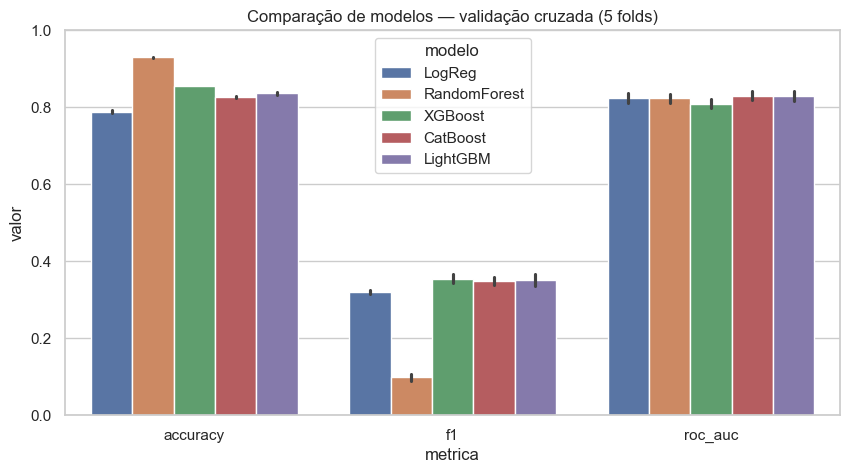

In [5]:
plt.figure(figsize=(10, 5))
sns.barplot(data=resultados, x='metrica', y='valor', hue='modelo', errorbar='sd')
plt.title('Comparação de modelos — validação cruzada (5 folds)')
plt.ylim(0, 1)
plt.savefig('../reports/comparacao_modelos_cv.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Avaliação do melhor modelo no conjunto de teste

Ajuste `MELHOR_MODELO` conforme o resultado da comparação acima (maior F1/ROC-AUC médios).

In [6]:
MELHOR_MODELO = 'XGBoost'

pipeline_final = Pipeline([
    ('preprocessador', construir_preprocessador()),
    ('modelo', modelos[MELHOR_MODELO]),
])
pipeline_final.fit(X_train, y_train)

pred = pipeline_final.predict(X_test)
proba = pipeline_final.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print('ROC-AUC:', round(roc_auc_score(y_test, proba), 4))

              precision    recall  f1-score   support

           0       0.96      0.87      0.92     13588
           1       0.26      0.58      0.36      1044

    accuracy                           0.85     14632
   macro avg       0.61      0.73      0.64     14632
weighted avg       0.91      0.85      0.88     14632

ROC-AUC: 0.8177


**Comentário:** no teste, o XGBoost confirma o F1 da validação cruzada (**0,36**) e melhora a precisão da classe fatal em relação ao baseline (0,26 vs. 0,21), mas com um trade-off importante: o recall cai de 0,72 (LogReg) para **0,58** — identifica menos acidentes fatais, com menos falsos alarmes. Qual modelo é "melhor" depende do custo de cada erro: se deixar passar um acidente fatal é mais grave do que gerar um alarme falso, o baseline (maior recall) pode ser preferível ao XGBoost (maior F1/precisão), mesmo este tendo o F1 mais alto — e CatBoost/LightGBM (melhor ROC-AUC na CV) seriam candidatos a testar nesse cenário. Essa decisão cabe a quem for usar o modelo, não só à métrica agregada.

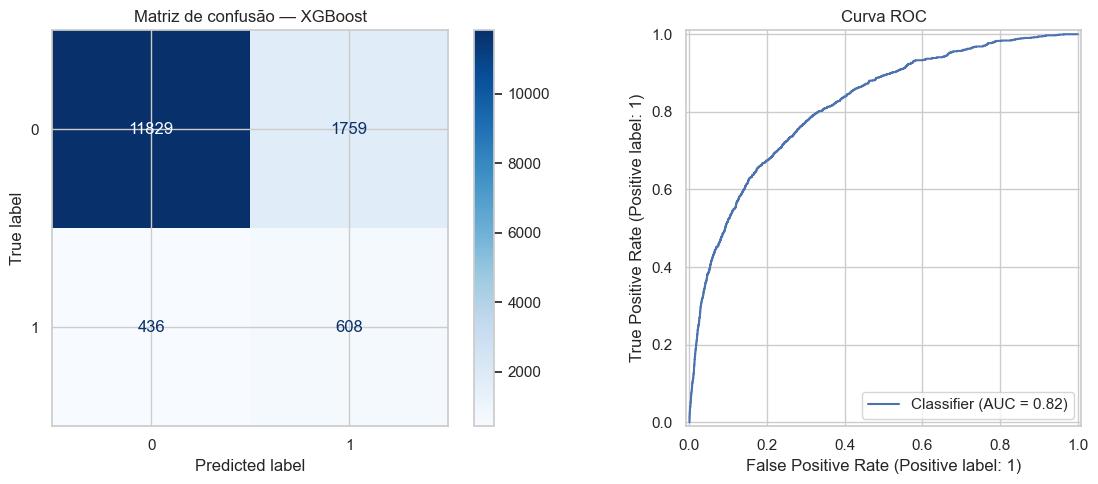

In [7]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap='Blues', ax=eixos[0])
eixos[0].set_title(f'Matriz de confusão — {MELHOR_MODELO}')
RocCurveDisplay.from_predictions(y_test, proba, ax=eixos[1])
eixos[1].set_title('Curva ROC')
plt.tight_layout()
plt.savefig('../reports/melhor_modelo_avaliacao.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Salvar modelo

In [8]:
joblib.dump(pipeline_final, f'../models/{MELHOR_MODELO.lower()}_cv.joblib')

['../models/xgboost_cv.joblib']

## 8. Próximos passos
- Otimização bayesiana de hiperparâmetros com Optuna → `04_Otimizacao_Optuna.ipynb`